## Task 2 (a) - Naive Bayes Classifier
### Data Preparation

In [1]:
# import libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import cross_val_score

In [2]:
# loading train and test datasets 
train_dataset = pd.read_csv('train.csv')
test_dataset = pd.read_csv('test.csv')

In [3]:
# define classification inputs and class labels 
X_train = train_dataset['Article']
y_train = train_dataset['Category']

X_test = test_dataset['Article']
y_test = test_dataset['Category']

In [4]:
# vectorise the train and test text using TF-IDF vectorisation (to be consistent with the other 3 models)
vectorizer = TfidfVectorizer()

X_train_vectorized = vectorizer.fit_transform(X_train) 
X_test_vectorized = vectorizer.transform(X_test) 

In [5]:
# define and train a multinomial Naive Bayes model 
NB_model = MultinomialNB()
NB_model.fit(X_train_vectorized, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


### 2(a)(i) Top 20 Predictive Words

In [6]:
# Get most predictive words for both classes and print 
class_list = list(NB_model.classes_)
word_list = vectorizer.get_feature_names_out()

for i in range(len(class_list)): 
    class_label = class_list[i] 
    predictive_scores = NB_model.feature_log_prob_[i]
    top20_pred_indices = np.argsort(predictive_scores)[::-1][:20]
    top20_pred_words = [word_list[j] for j in top20_pred_indices]
    print(f"Top 20 most predictive words for '{class_label}': {top20_pred_words}")

Top 20 most predictive words for 'entertainment': ['film', 'best', 'said', 'show', 'band', 'music', 'year', 'awards', 'us', 'award', 'actor', 'album', 'star', 'chart', 'tv', 'also', 'number', 'oscar', 'top', 'new']
Top 20 most predictive words for 'tech': ['said', 'people', 'mobile', 'software', 'games', 'phone', 'net', 'users', 'technology', 'mr', 'microsoft', 'virus', 'computer', 'broadband', 'new', 'use', 'could', 'would', 'digital', 'game']


### 2(a)(ii) Top 20 Discriminative Words

In [7]:
# Get most discriminative words for both classes and print
tech_scores = NB_model.feature_log_prob_[class_list.index('tech')]
entertainment_scores = NB_model.feature_log_prob_[class_list.index('entertainment')]

# Top 20 most discriminative words for tech class 
discriminative_scores_tech = tech_scores - entertainment_scores
top20_disc_indices_tech = np.argsort(discriminative_scores_tech)[::-1][:20]
top20_disc_words_tech = [word_list[j] for j in top20_disc_indices_tech]
print(f"Top 20 most discriminative words for tech: {top20_disc_words_tech}")

# Top 20 most discriminative words for entertainment class 
discriminative_scores_ent = entertainment_scores - tech_scores 
top20_disc_indices_ent = np.argsort(discriminative_scores_ent)[::-1][:20]
top20_disc_words_ent = [word_list[j] for j in top20_disc_indices_ent]
print(f"Top 20 most discriminative words for entertainment: {top20_disc_words_ent}")



Top 20 most discriminative words for tech: ['mobile', 'software', 'users', 'microsoft', 'games', 'net', 'technology', 'virus', 'phone', 'broadband', 'computer', 'phones', 'spam', 'mail', 'firms', 'use', 'spyware', 'online', 'pc', 'internet']
Top 20 most discriminative words for entertainment: ['film', 'band', 'best', 'actor', 'album', 'chart', 'oscar', 'singer', 'award', 'actress', 'star', 'musical', 'stars', 'festival', 'comedy', 'awards', 'aviator', 'theatre', 'rock', 'nominated']


### Which list of words describes the two classes better? 
The discriminative word lists better describe the two classes because they highlight the words that most strongly distinguish tech articles from entertainment articles.

The most predictive words are the words with the highest conditional probabilities within each class, which may include common words that appear frequently across both classes, such as ‘said’ and ‘new’, and therefore do not provide useful information to describe each class or discriminate between them.

The most discriminative words use the ratio P(word|tech) / P(word|entertainment) to isolate words that are specific to the tech class, such as ‘mobile’ and ‘software’. The inverse ratio P(word|entertainment) / P(word|tech) isolates entertainment-specific words to describe the entertainment class. Therefore, the discriminative lists give a more precise and informative description of the classes.

## Task 3 (a) - Hyperparameter Tuning
### NB hyperparameters

The hyperparameters for the multinomial Naive Bayes classifier are limited compared to other models.

The Laplace smoothing constant alpha (which is set to a default of 1.0) is the primary hyperparameter we will be investigating. 

The following code tests the performance (measured by 5-fold cross-validation F1 score) of the NB classifier with alpha values of 0.01, 0.1, 0.5, 1.0, 2.0 and 5.0.

In [8]:
# implement 5-fold cross validation for the NB model 
def calculate_cv_performance(NB_model, X_train_vectorized, y_train):
    cv_evaluation = cross_val_score(NB_model, X_train_vectorized, y_train, cv=5, scoring='f1_weighted')
    cv_performance = np.mean(cv_evaluation)
    return cv_performance  

In [9]:
# test how hyperparameter alpha impacts the model performance (using cross-validation evaluation) 
alpha_test_values = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0]
alpha_cv_performance = [] 

for value in alpha_test_values: 
    NB_test_model = MultinomialNB(alpha=value)
    cv_performance = calculate_cv_performance(NB_test_model, X_train_vectorized, y_train)
    alpha_cv_performance.append(cv_performance)
    
    print(f"alpha = {value}, cv_performance = {cv_performance}")

alpha = 0.01, cv_performance = 0.9813374390055151
alpha = 0.1, cv_performance = 0.983663963841592
alpha = 0.5, cv_performance = 0.9813374390055151
alpha = 1.0, cv_performance = 0.976673684745718
alpha = 2.0, cv_performance = 0.9743389701394453
alpha = 5.0, cv_performance = 0.9696568694869463


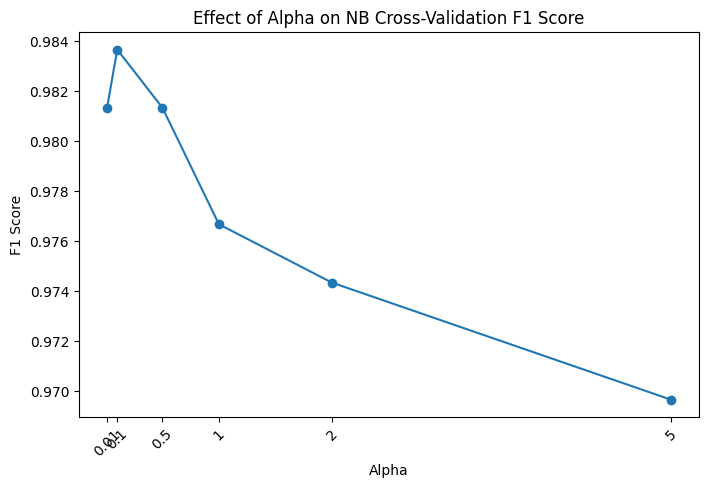

In [10]:
# plot the F1 performance of each alpha value 
plt.figure(figsize=(8, 5))
plt.plot(alpha_test_values,
         alpha_cv_performance,
         marker='o')

plt.xticks(alpha_test_values,
           ['0.01', '0.1', '0.5', '1', '2', '5'],
           rotation=45)
plt.xlabel('Alpha')
plt.ylabel('F1 Score')
plt.title('Effect of Alpha on NB Cross-Validation F1 Score')

plt.show()

### How the hyperparameter impacts model performance
From these results (summarised in the graph) we can see how the alpha impacts the model's cross validation performance: 

Alpha = 0.1 achieves the highest cross-validation F1 score of 0.9837. Then as alpha increases, the F1 score decreases, suggesting that a relatively low amount of smoothing works better for this dataset. We will therefore choose alpha = 0.1 as the best alpha setting. 

## Task 3 (b) - Model Evaluation with the best hyperparameter settings 

In [11]:
# define and train the final naive bayes classifier using the best hyperparameter setting alpha = 0.1 
NB_final_model = MultinomialNB(alpha=0.1) 
NB_final_model.fit(X_train_vectorized, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",0.1
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [12]:
# F1 score on the test dataset using the final naive bayes model 
y_pred = NB_final_model.predict(X_test_vectorized)
print(classification_report(y_test, y_pred))
print(f"Weighted F1 Score: {f1_score(y_test, y_pred, average='weighted')}")

               precision    recall  f1-score   support

entertainment       1.00      0.95      0.97        61
         tech       0.94      1.00      0.97        45

     accuracy                           0.97       106
    macro avg       0.97      0.98      0.97       106
 weighted avg       0.97      0.97      0.97       106

Weighted F1 Score: 0.971797848780413


## Task 3 (c) - Effect of training data set size on NB test and train accuracy 

In [13]:
# calculate the train and test accuracies for each of the training subsets 
train_subsets = [0.1, 0.3, 0.5, 0.7, 0.9] 
train_accuracies = []
test_accuracies = [] 


for m in train_subsets: 
    mN = int(m * X_train_vectorized.shape[0])
    X_train_subset = X_train_vectorized[0:mN]
    y_train_subset = y_train[0:mN]
    NB_subset_model = MultinomialNB(alpha=0.1)
    NB_subset_model.fit(X_train_subset, y_train_subset)
    train_subset_pred = NB_subset_model.predict(X_train_subset)
    train_accuracy = f1_score(y_train_subset, train_subset_pred, average = 'weighted')
    test_pred = NB_subset_model.predict(X_test_vectorized) 
    test_accuracy = f1_score(y_test, test_pred, average = 'weighted') 

    train_accuracies.append(train_accuracy) 
    test_accuracies.append(test_accuracy) 

print(train_accuracies)
print(test_accuracies)



[1.0, 1.0, 1.0, 1.0, 0.9948051948051948]
[0.8586794971912235, 0.971797848780413, 0.9623598578069456, 0.9624274506868795, 0.9811799289034726]


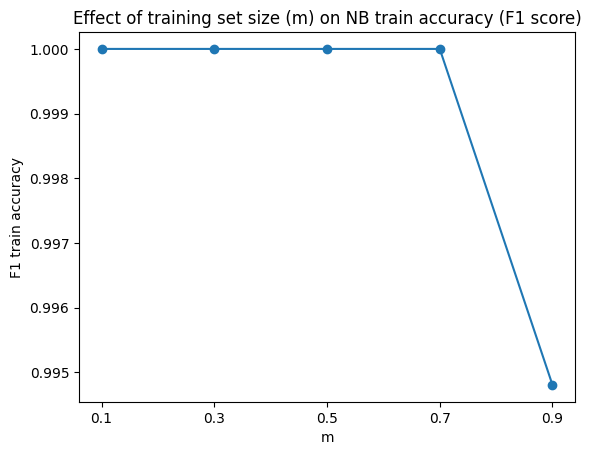

In [14]:
# plot train accuracy 
plt.plot(train_subsets, train_accuracies, marker='o')
plt.xticks(train_subsets)

plt.xlabel('m')
plt.ylabel('F1 train accuracy')
plt.title('Effect of training set size (m) on NB train accuracy (F1 score)')

plt.show()

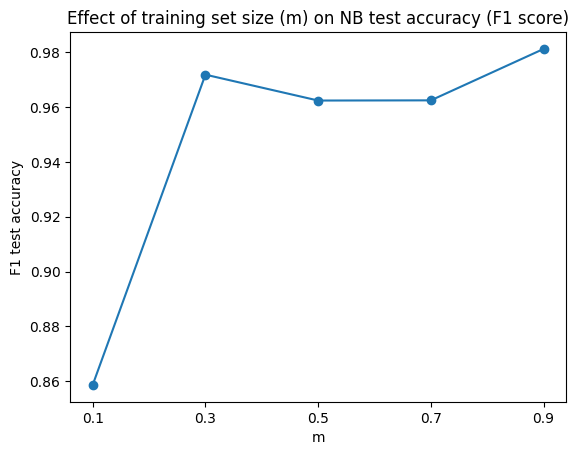

In [15]:
# plot test accuracy 
plt.plot(train_subsets, test_accuracies, marker='o')
plt.xticks(train_subsets)

plt.xlabel('m')
plt.ylabel('F1 test accuracy')
plt.title('Effect of training set size (m) on NB test accuracy (F1 score)')

plt.show()

### General trend of the two plots (NB) 
The training accuracy was high (near 1.0) for all values of m, with only a slight decrease at m = 0.9. This is because with smaller training subsets, the model can easily fit the limited number of instances, correctly predicting almost all training examples. However, this high training accuracy suggests overfitting, as the model is fitting very closely to the training data rather than learning more general patterns. 

In general, testing accuracy improved as m increased, although there were some fluctuations. The test accuracy started at 0.8587 for m = 0.1 and increased to 0.9812 for m = 0.9. This suggests that more training data allows the model to learn more general patterns that transfer better to unseen test data. 

The contrasting trends in the two plots highlight the trade-off between overfitting and generalisation. A model trained on a small training set may fit that data extremely well but struggle to generalise, while more training data leads to better test accuracy, even if the training accuracy decreases slightly.
